In [84]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import boxcox, normaltest, skew

In [85]:
df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv", index_col = 0)

## Data Visualization

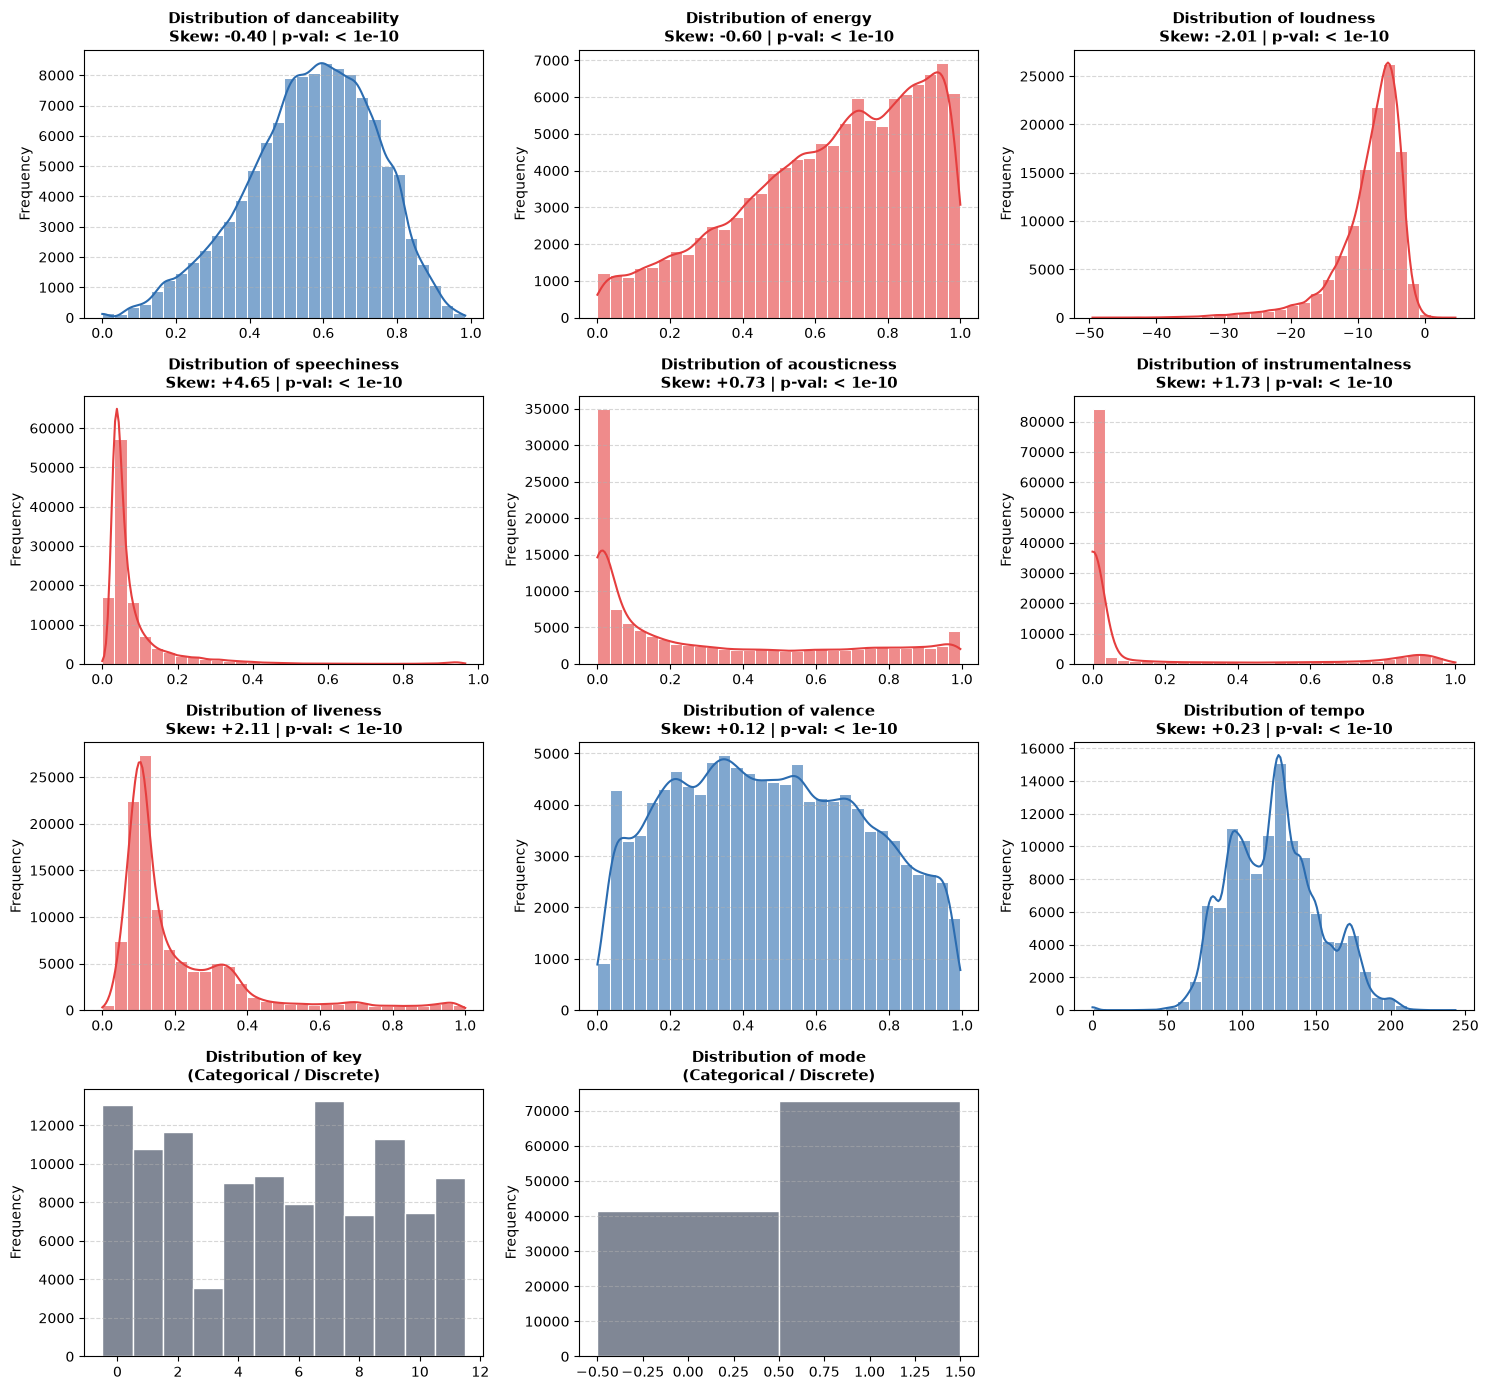

Non-normal variables detected by normaltest (9/9):
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [86]:
def plot_feature_distributions(df, numeric_cols, categorical_cols, cols, rows):
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
    axes = axes.flatten()

    all_cols = numeric_cols + categorical_cols
    skewed_vars = []

    # 1. Plot Numeric Features with Skewness & Normality Tests
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        clean_series = df[col].dropna()

        # Statistical calculations
        val_skew = skew(clean_series)
        stat, p_val = normaltest(clean_series)

        is_non_normal = p_val < 0.05
        if is_non_normal:
            skewed_vars.append(col)

        # Highlight skewed features (|skew| > 0.5) in coral/red, otherwise blue
        bar_color = "#E53E3E" if abs(val_skew) > 0.5 else "#2B6CB0"

        sns.histplot(
            clean_series,
            bins=30,
            kde=True,
            ax=ax,
            color=bar_color,
            edgecolor="white",
            alpha=0.6,
        )

        # Annotated title
        p_text = "< 1e-10" if p_val < 1e-10 else f"{p_val:.1e}"
        ax.set_title(
            f"Distribution of {col}\n"
            f"Skew: {val_skew:+.2f} | p-val: {p_text}",
            fontsize=11,
            fontweight="bold",
        )
        ax.set_xlabel("")
        ax.set_ylabel("Frequency", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    # 2. Plot Categorical / Discrete Features
    offset = len(numeric_cols)
    for j, col in enumerate(categorical_cols):
        ax = axes[offset + j]
        clean_series = df[col].dropna()

        sns.histplot(
            clean_series,
            discrete=True,
            ax=ax,
            color="#4A5568",
            edgecolor="white",
            alpha=0.7,
        )

        ax.set_title(
            f"Distribution of {col}\n(Categorical / Discrete)",
            fontsize=11,
            fontweight="bold",
        )
        ax.set_xlabel("")
        ax.set_ylabel("Frequency", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    # 3. Remove any unused subplot axes
    for k in range(len(all_cols), len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

    print(
        f"Non-normal variables detected by normaltest ({len(skewed_vars)}/{len(numeric_cols)}):"
    )
    print(skewed_vars)


# Feature lists
numeric_cols = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

categorical_cols = ["key", "mode"]

cols = 3
rows = math.ceil(len(numeric_cols + categorical_cols) / cols)

plot_feature_distributions(df, numeric_cols, categorical_cols, cols, rows)

In [87]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Data Cleaning and Processing
The [dataset](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) shows the cleanliness and provides documentation on the column names and values, which will be used in this section

In [88]:
# https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset

print(f"Number of Rows: {len(df)}")

feature_cols = numeric_cols + categorical_cols

# drop any null rows and duplicate rows
df = df.dropna(subset=feature_cols).reset_index(drop=True)
df = df.drop_duplicates(subset=["track_id"]).reset_index(drop=True)
print(f"Number of Clean Rows: {len(df)}")

Number of Rows: 114000
Number of Clean Rows: 89741


### Column Values
As for processing though, certain audio features are scaled to between 0 and 1 so that it will not dominate distance calculations for nearest neighbors model
- `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveliness`, `valence` $\rightarrow$ float 0 - 11
- `key` $\rightarrow$ int 0 - 11
- `loudness` $\rightarrow$ float -49.53 - 4.53 dB
- `mode` $\rightarrow$ int 0 or 1
- `tempo` $\rightarrow$ float 0 - 243 bpm

### Tempo
According to [Krumhansl](https://cogsci.northwestern.edu/events/2016-2017-events/Krumhansl_2000.pdf), if the time between each beat is more than 1.5 seconds, then listeners have difficulty grouping sounds. As such, 40 BPM $60 / 1.5 = 40$ will be used as the bare minimum of what is considered "music". Unfortunately, this column is machine generated and Spotify's algorithm has trouble classifying BPM for all songs accurately. I will be dropping songs below 40 BPM

### Key
Treating Key as linear is not feasible because it wraps around. 0 (C) and 11 (B) are adjacent semitones (just 1 key apart on the piano), but are treated as maximally distant from one another. Although musical key definitely contributes to how music sounds, I'll be dropping it because the harmonics are less important than the other features

### Loudness
Loudness has a negative skew because decibels are a logarithmic scale. I will use percentile-based clipping for loudness

### Tempo Doubling/Halving
Some songs might have their BPMs halved while others doubled. For example, 120 BPM might be represented as 60, 120, or even 240 BPM. While I love music, I will not be listening to the 100k+ songs to clean the bpm data. I do think bpm is still important enough to keep in, despite the possible discrepancies.

### Instrumentalness, Acousticness, Speechiness, Liveliness, Energy
Instrumentalness, Acousticness, Speechiness, Liveliness are all positively skewed. Energy is negatively skewed. I will apply a transformation to each feature to each one

### Mode
Mode is binary (0 = minor, 1 = major), which can represent a large swing in distance for a nearest neighbors model. 

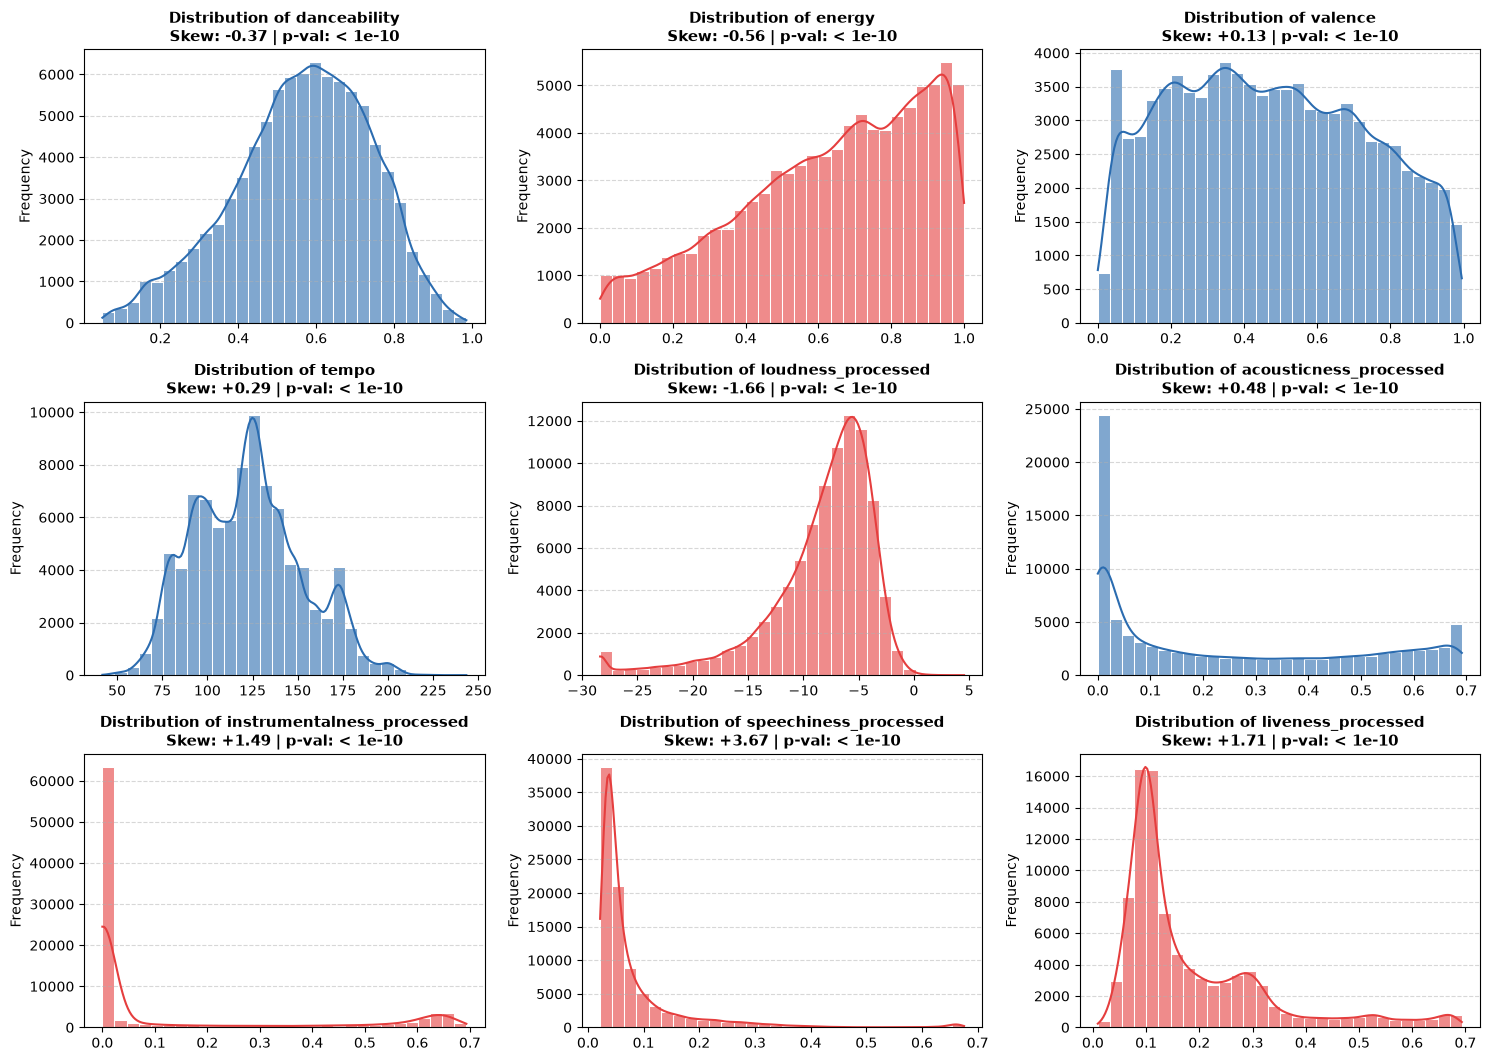

Non-normal variables detected by normaltest (9/9):
['danceability', 'energy', 'valence', 'tempo', 'loudness_processed', 'acousticness_processed', 'instrumentalness_processed', 'speechiness_processed', 'liveness_processed']


In [89]:
# Filter out songs with missing or invalid tempo
df = df[df["tempo"] > 40.0].reset_index(drop=True)

# clip loudness to the 1st percentile to avoid extreme negative compression
lower_loudness = df["loudness"].quantile(0.01)
df["loudness_processed"] = df["loudness"].clip(lower=lower_loudness)

# transform heavy right-skewed features using log1p: log(1 + x)
right_skewed_features = ["instrumentalness", "speechiness", "liveness", "acousticness"]
for feature in right_skewed_features:
    df[f"{feature}_processed"] = np.log1p(df[feature])

# features to use in the final model (excluding key, keeping mode with downweighted impact)
model_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness_processed",
    "acousticness_processed",
    "instrumentalness_processed",
    "speechiness_processed",
    "liveness_processed",
]

plot_feature_distributions(df, model_features, [], cols, rows)

In [91]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[model_features])

# Apply Domain Feature Weights
# Prioritize core vibe drivers (danceability, energy, valence, tempo)
feature_weights = np.array([1.2, 1.2, 1.2, 1.0, 0.8, 0.4, 0.8, 0.8, 0.3])
X_weighted = X_scaled * feature_weights

# Fit Nearest Neighbors Model
nn_model = NearestNeighbors(n_neighbors=50, metric="cosine", algorithm="brute")
nn_model.fit(X_scaled)

print(
    f"Model successfully trained on {len(df):,} songs across {X_scaled.shape[1]} features!"
)

print("Nearest Neighbors model fitted successfully!")

Model successfully trained on 89,567 songs across 9 features!
Nearest Neighbors model fitted successfully!


## Validate the Model

## Save the Model